<a href="https://colab.research.google.com/github/jess22jess/SIMULACI-IN-I/blob/main/L%C3%ADnea_de_Espera_0_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Arcos Gutiérrez Jessica Beatriz

Simulación I

---
# Línea de Espera



Aquí lo que hacemos es importar las librerías, esto además de servir para que podamos usarlas, también nos permite escribir menos. Así si voy a crear una gráfica o lo que es un "número aleatorio" usamos plt y r, y después de ambos se pone un punto para ya ocuparlo del modo que necesitemos.

In [1]:
import random as r
import numpy as np
import matplotlib.pyplot as plt

En este apartado lo que estamos haciendo es generar tiempos aleatorios para lo que son el tiempo de llegada y el tiempo de servicio, **dónde lambda es la tasa de llegadas y mu es la tasa de servicio.**

**Nota:** Si lambda es grande, entonces el tiempo de llegadas es pequeño, de lo contrario (si es pequeño) el tiempo de llegadas es grande, y si mu es grande el tiempo de servicio es pequeño, de igual manera si es pequeño el tiempo de servicio es grande.

Básicamente lo que hicimos para esta parte fue aplicar el método de la **Transformada Inversa**.

In [2]:
def tiempo_llegada(lam):
    u = r.random()
    return -np.log(u) / lam

def tiempo_servicio(mu):
    u = r.random()
    return -np.log(u) / mu

Para indicar que hace cada variable:
---
---
* t = 0.0 es el tiempo actual
* NA = 0 es el número de llegadas hasta ahora
* ND = 0 es el número de salidas hasta ahora
* n = 0  son los clientes en el sistema
---
* A = [] es el tiempo de llegada
* D = [] es el tiempo de salida
---
   
* tA = tiempo_llegada(lam) es la primera llegada
* tD = float("inf") indica que no hay nadie atendiendo al inicio


**Para el CASO I**
---
* t = tA aquí lo que hacemos es avanzar el tiempo hasta la llegada
* NA = NA + 1 quiere decir que llegó un cliente más
* n = n + 1 ya hay un cliente más en sistema
* A.append(t) con append lo que hacemos es guardar cuándo llegó este cliente
---

* tA = t + tiempo_llegada(lam) lo que buscamos es programar la siguiente llegada
----
Esta parte del código nos dice que si era el único cliente entonces el sistema estaba vacío, por lo que se le empieza a atender ahora.

if n == 1:        

tD = t + tiempo_servicio(mu)  

**Para el CASO II**
---
* t = tD hacemos que avance el tiempo hasta la salida
* n = n - 1 esto significa que un cliente se va del sistema
* ND = ND + 1 incrementamos el contador de salidas
* D.append(t) guardamos cuándo salió este cliente
---
En este punto, si ya no quedan clientes, entonces no hay una próxima salida, de otro modo, si aún quedan clientes en fila, el siguiente empieza a ser atendido.

if n == 0:          

tD = float("inf")     

else:                        

tD = t + tiempo_servicio(mu)  

Para el CASO III
---
* t = tD de igual manera avanzamos hasta la siguiente salida
* n = n - 1 el cliente se va
* ND = ND + 1 hay una salida más
* D.append(t) se guarda la salida
---
Ahora, si aún quedan más, se atiende al sigiuente. De otro modo, quiere decir que ya no hay nadie.

if n > 0:

tD = t + tiempo_servicio(mu)  

else:             

tD = float("inf")        

Para el CASO IV
---
* Tp = max(t - T, 0) se refiere a cuánto tiempo después de T terminó
* break lo que hace es salir del while (o sea que se termina la ejecución)

In [3]:
def simular(lam, mu, T):
    t = 0.0
    NA = 0
    ND = 0
    n = 0

    A = []
    D = []

    tA = tiempo_llegada(lam)
    tD = float("inf")

    while True:  # Esto indica que se va a repetir hasta que termine el sistema (esto es, hasta llegar al Caso 4)
        if tA <= tD and tA <= T:  # Caso 1: Llegada antes que salida y antes de T
            t = tA
            NA = NA + 1
            n = n + 1
            A.append(t)

            tA = t + tiempo_llegada(lam)

            if n == 1:
                tD = t + tiempo_servicio(mu)

        elif tD < tA and tD <= T:  # Caso 2: Salida antes que llegada y antes de T
            t = tD
            n = n - 1
            ND = ND + 1
            D.append(t)

            if n == 0:
                tD = float("inf")
            else:
                tD = t + tiempo_servicio(mu)

        elif tA > T and n > 0: # Caso 3: Ya pasó T pero hay clientes
            t = tD
            n = n - 1
            ND = ND + 1
            D.append(t)

            if n > 0:
                tD = t + tiempo_servicio(mu)
            else:
                tD = float("inf")

        elif tA > T and n == 0: # Caso 4: Ya pasó T y sistema vacío
            Tp = max(t - T, 0)
            break

    tiempos_en_sistema = []
    for i in range(len(A)):
        tiempos_en_sistema.append(D[i] - A[i])

    promedio = sum(tiempos_en_sistema) / len(tiempos_en_sistema) if len(tiempos_en_sistema) > 0 else 0

    return {   # Devuelve un diccionario con los resultados de esta ejecución
        "NA": NA,
        "ND": ND,
        "promedio_sistema": promedio,
        "Tp": Tp
    }

In [4]:
lam = 4.0
mu = 6.0
T = 10.0
num_ejecuciones = 1000

resultados = []

for i in range(num_ejecuciones):
    resultado = simular(lam, mu, T)
    resultados.append(resultado)

In [5]:
promedios_sistema = []
Tp_todos = []

for r in resultados:
    promedios_sistema.append(r["promedio_sistema"])
    Tp_todos.append(r["Tp"])

promedio_final_sistema = sum(promedios_sistema) / len(promedios_sistema)
promedio_final_Tp = sum(Tp_todos) / len(Tp_todos)


In [6]:
print(f"Tiempo promedio en sistema: {promedio_final_sistema:.4f}")
print(f"Tiempo posterior a T promedio: {promedio_final_Tp:.4f}")

Tiempo promedio en sistema: 0.4367
Tiempo posterior a T promedio: 0.3306


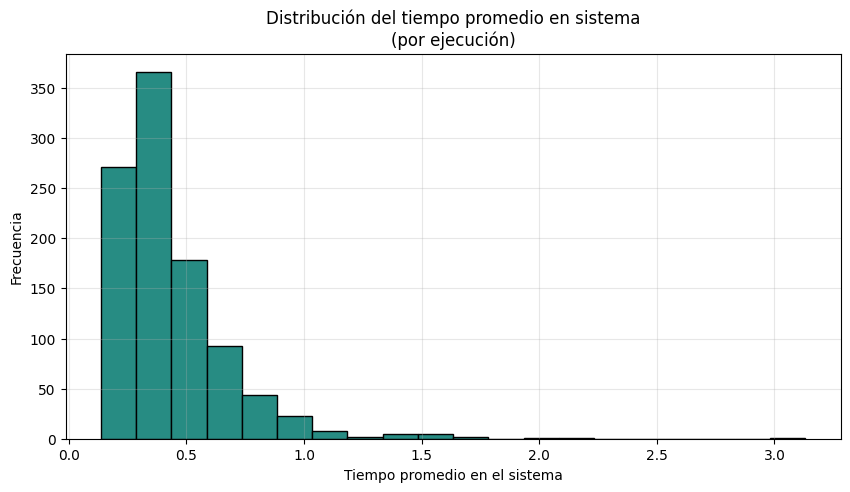

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(promedios_sistema, bins=20, edgecolor='black', color='#278C83')
plt.xlabel('Tiempo promedio en el sistema')
plt.ylabel('Frecuencia')
plt.title('Distribución del tiempo promedio en sistema\n(por ejecución)')
plt.grid(True, alpha=0.3)

plt.show()


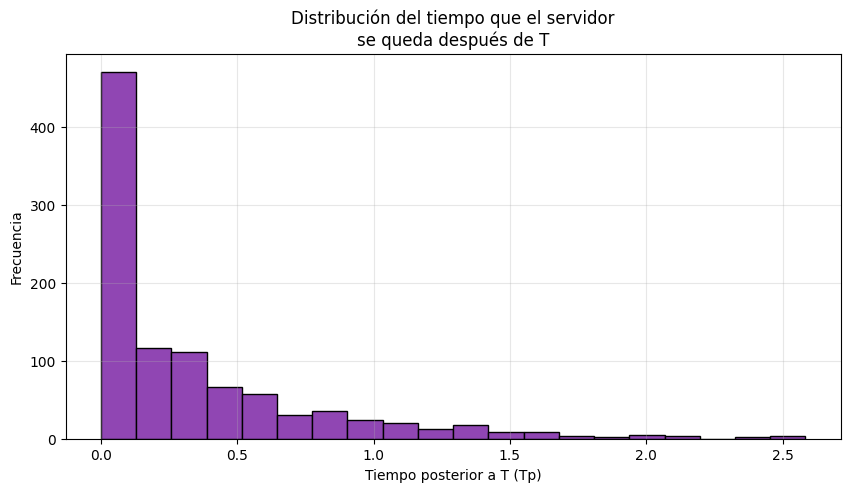

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(Tp_todos, bins=20, edgecolor='black', color='#9046B3')
plt.xlabel('Tiempo posterior a T (Tp)')
plt.ylabel('Frecuencia')
plt.title('Distribución del tiempo que el servidor\nse queda después de T')
plt.grid(True, alpha=0.3)


plt.show()
